<a href="https://colab.research.google.com/github/deorebhumika06/ai-projects/blob/main/neural%20network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
df=pd.read_csv("/content/Best Selling Mobile Phones 2020.csv")
df.head()

,No,Phone,Company,Sold(million)
0,1,iPhone 12 and iPhone 12 Mini,Apple,38.0
1,2,"Galaxy S20, S20+, S20 Ultra",Samsung,28.0
2,3,iPhone SE 2nd generation,Apple,24.2
3,4,Galaxy A21s,Samsung,19.4
4,5,iPhone 12 Pro Max,Apple,16.8


In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df[['Phone', 'Company']]
y = df['Sold(million)']

# Identify categorical features
categorical_features = ['Phone', 'Company']

# Create a ColumnTransformer for one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply preprocessing to the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Data preparation complete!")
print(f"Shape of processed training data: {X_train_processed.shape}")
print(f"Shape of processed testing data: {X_test_processed.shape}")

Data preparation complete!
Shape of processed training data: (5, 8)
Shape of processed testing data: (2, 8)


Now that the data is preprocessed, let's define and build the neural network for regression.

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Determine the input dimension for the neural network
input_dim = X_train_processed.shape[1]

# Build the neural network model
model = Sequential([
    Dense(64, activation='relu', input_dim=input_dim),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression (single output)
])

# Compile the model for regression
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
history = model.fit(
    X_train_processed, y_train,
    epochs=100,  # You can adjust the number of epochs
    validation_data=(X_test_processed, y_test),
    verbose=0 # Set to 1 for progress bar
)

print("Training complete!")

Training complete!


Test Loss (Mean Squared Error): 617.27
Test MAE (Mean Absolute Error): 24.55


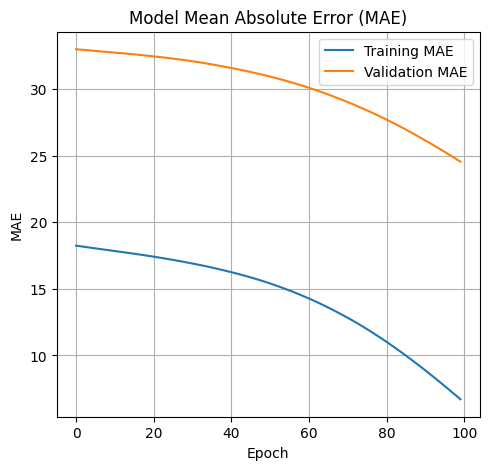

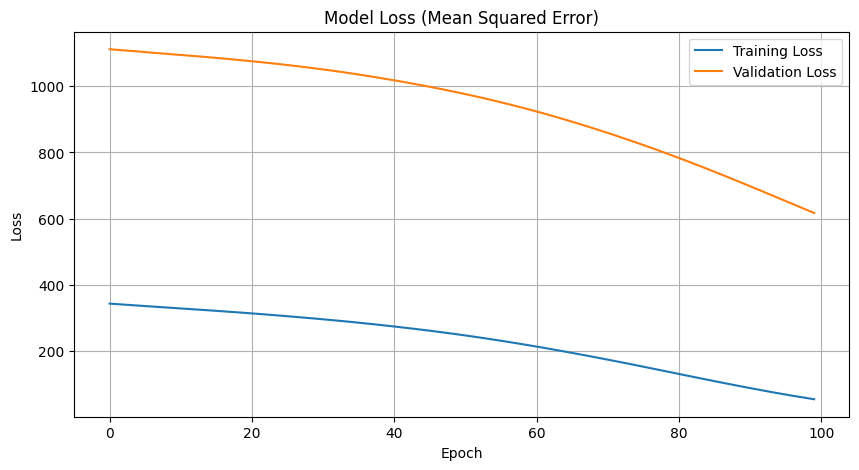

<Figure size 640x480 with 0 Axes>

In [53]:
import matplotlib.pyplot as plt

# Evaluate the model on the test set
loss, mae = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"Test Loss (Mean Squared Error): {loss:.2f}")
print(f"Test MAE (Mean Absolute Error): {mae:.2f}")

# Plotting training and validation MAE (as a proxy for what accuracy might represent in regression)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error (MAE)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

# Plotting training and validation loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.tight_layout()
plt.show()

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
df=pd.read_csv("/content/gender_classification_v7.csv")
df


,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [78]:
df.describe().round()/len(df)*100

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.019996,0.259948,0.119976,0.000000,0.019996,0.000000,0.000000
std,0.000000,0.019996,0.019996,0.019996,0.000000,0.019996,0.019996
min,0.000000,0.219956,0.099980,0.000000,0.000000,0.000000,0.000000
25%,0.019996,0.239952,0.119976,0.000000,0.000000,0.000000,0.000000
50%,0.019996,0.259948,0.119976,0.000000,0.019996,0.000000,0.000000
75%,0.019996,0.279944,0.119976,0.019996,0.019996,0.019996,0.019996
max,0.019996,0.319936,0.139972,0.019996,0.019996,0.019996,0.019996


In [79]:
df.isnull().sum()/len(df)*100

,0
long_hair,0.0
forehead_width_cm,0.0
forehead_height_cm,0.0
nose_wide,0.0
nose_long,0.0
lips_thin,0.0
distance_nose_to_lip_long,0.0
gender,0.0
